In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from sklearn import metrics
from sklearn import linear_model

In [2]:
# Load datasets. These were downloaded from NHANES website (2017-2018 cycle) 
demo = pd.read_sas(r"C:\Users\brigi\Downloads\NHANES 2017-2018\DEMO_J.xpt")
slq = pd.read_sas(r"C:\Users\brigi\Downloads\NHANES 2017-2018\SLQ_J.xpt")
dpq = pd.read_sas(r"C:\Users\brigi\Downloads\NHANES 2017-2018\DPQ_J.xpt")

In [3]:
print(demo.shape)
print(slq.shape)
print(dpq.shape)

(9254, 46)
(6161, 11)
(5533, 11)


In [4]:
# The income variable we want is INDFMPIR, which is the ratio of family income to poverty. 
# We will merge this with the sleepiness and depression datasets. But let's look at it first.
# Pull just the SEQN and INDFMPIR columns from the demo dataset, and call describe on INDFMPIR
income = demo[['SEQN', 'INDFMPIR']]
income['INDFMPIR'].describe()

count    8.023000e+03
mean     2.375490e+00
std      1.600291e+00
min      5.397605e-79
25%      1.040000e+00
50%      1.920000e+00
75%      3.690000e+00
max      5.000000e+00
Name: INDFMPIR, dtype: float64

In [5]:
# How many missing values are there in the income variable?
income['INDFMPIR'].isna().sum()

np.int64(1231)

1,231 out of 9,254 participants (~13%) have no income data. We'll lose these people when we do the merge and drop NA values. It's worth noting that people who don't report income may differ systematically from those who do.

The distribution of the income ratio variable is interesting. It looks like a lot of people are clustered around the lower ranges, so it could be a right-skewed distribution.

In [10]:
# Merge the three dataframes, two sequential inner joins on SEQN, starting with slq and dpq, then merging in the income dataset.
df = slq.merge(dpq, on='SEQN', how='inner').merge(income, on='SEQN', how='inner')

In [11]:
df.shape

(5533, 22)

In [12]:
# Clean the data
dpq_cols = ['DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060', 'DPQ070', 'DPQ080', 'DPQ090']
# Round depression and sleepiness variables to nearest integer
df[['SLQ120'] + dpq_cols] = df[['SLQ120'] + dpq_cols].round()
# Replace 7 and 9 with NaN in the depression and sleepiness variables
df[['SLQ120'] + dpq_cols] = df[['SLQ120'] + dpq_cols].replace([7,9], float('nan'))
# Drop NaN values from the depression, sleepiness, and income variables
df = df.dropna(subset=['SLQ120'] + dpq_cols + ['INDFMPIR'])
df.shape

(4433, 22)

We went from 5,533 participants after the inital merge to 4,433 after dropping missing values, losing roughly 1,100 people mostly due to missing income data.

In [13]:
# Compute the PHQ-9 score by summing the depression variables
df['PHQ9'] = df[dpq_cols].sum(axis=1)
# Create a binary outcome variable for depression, where 1 = PHQ-9 score >= 10, and 0 = PHQ-9 score < 10
df['depression'] = np.where(df['PHQ9'] >= 10, 1, 0)
df['depression'].value_counts()

depression
0    4041
1     392
Name: count, dtype: int64

The data is imbalanced, which we would expect: 9% depressed, 91% not. So when we eventually create a model to predict the outcome, it needs to do better than 91% since we could predict all zeros and the data would indicate 91% accuracy of an all-zero prediction. 

In [14]:
# Stage 1: Logistic regression - Depression as a function of sleepiness. (We'll add income later.)
# Define X (predictor) and y (outcome)
X = df[['SLQ120']]
y = df['depression']
# Add a constant to the predictor variable (for the intercept)
X = sm.add_constant(X)
# Fit the logistic regression model
model = sm.Logit(y, X).fit()
# Print the summary of the model
model.summary()

Optimization terminated successfully.
         Current function value: 0.275115
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             depression   No. Observations:                 4433
Model:                          Logit   Df Residuals:                     4431
Method:                           MLE   Df Model:                            1
Date:                Sun, 28 Jun 2026   Pseudo R-squ.:                 0.07953
Time:                        11:10:56   Log-Likelihood:                -1219.6
converged:                       True   LL-Null:                       -1325.0
Covariance Type:            nonrobust   LLR p-value:                 9.452e-48
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.8533      0.139    -27.789      0.000      -4.125      -3.582
SLQ120         0.6954      0.051     13.762      0.000       0.596       0.794
==============================================================================
"""

In [24]:
# Compute the odds ratio by exponentiating the coefficient
np.exp(model.params) # This is the odds ratio for sleepiness (SLQ120)

const     0.021210
SLQ120    2.004488
dtype: float64

And odds ratio of 2 for the daytime sleepiness parameter means that each one-level increase in daytime sleepiness is associated with approximately double the odds of screening positive for depression. 

In [25]:
# Get the confidence interval for the odds ratio
np.exp(model.conf_int())

,0,1
const,0.016163,0.027834
SLQ120,1.815489,2.213163


1. This model shows that daytime sleepiness significantly predicts depression. 
2. The odds ratio, in plain English, describes the change in odds resulting from a change in the predictor. An odds ratio of 2 for this model means that any one-level change in daytime sleepiness (from "Sometimes" to "Often", for example) corresponds to two times the odds of scoring 10 or higher for the PHQ-9 depression score.
3. The Pseudo R^2, also called the McFadden's R^2, is 0.0795 which is corresponds to a "moderate" fit (between 0.05-0.10)

In [26]:
# Stage 2: Now let's fit two more models, one with income as a predictor, and one with both sleepiness and income as predictors.

# Model 2: Depression as a function of income
X = df[['INDFMPIR']]
y = df['depression']
X = sm.add_constant(X)
model2 = sm.Logit(y, X).fit()
model2.summary()


Optimization terminated successfully.
         Current function value: 0.291319
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             depression   No. Observations:                 4433
Model:                          Logit   Df Residuals:                     4431
Method:                           MLE   Df Model:                            1
Date:                Sun, 28 Jun 2026   Pseudo R-squ.:                 0.02531
Time:                        11:33:43   Log-Likelihood:                -1291.4
converged:                       True   LL-Null:                       -1325.0
Covariance Type:            nonrobust   LLR p-value:                 2.604e-16
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6823      0.091    -18.542      0.000      -1.860      -1.505
INDFMPIR      -0.2887      0.037     -7.783      0.000      -0.361      -0.216
==============================================================================
"""

In [27]:
# Model 3: Depression as a function of both sleepiness and income
X = df[['SLQ120', 'INDFMPIR']]
y = df['depression']
X = sm.add_constant(X)
model3 = sm.Logit(y, X).fit()
model3.summary()

Optimization terminated successfully.
         Current function value: 0.269280
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             depression   No. Observations:                 4433
Model:                          Logit   Df Residuals:                     4430
Method:                           MLE   Df Model:                            2
Date:                Sun, 28 Jun 2026   Pseudo R-squ.:                 0.09905
Time:                        11:35:24   Log-Likelihood:                -1193.7
converged:                       True   LL-Null:                       -1325.0
Covariance Type:            nonrobust   LLR p-value:                 1.011e-57
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.2057      0.160    -19.976      0.000      -3.520      -2.891
SLQ120         0.6695      0.051     13.243      0.000       0.570       0.769
INDFMPIR      -0.2611      0.038     -6.888      0.000      -0.335      -0.187
==============================================================================
"""

The odds ratio in model 2 (depression ~ income) is exp(-.2887) = 0.75 which means as income increases, the odds of scoring at least 10 on the depression screener goes down by 25%. Richer people had 25% lower odds of being clinically depressed.

The Pseudo R^2 for model 2 is 0.02531 which is negligible and less than the same measure for model 1, meaning that the income model doesn't fit depression scores as well as sleepiness does.

The coefficient for sleepiness decreased from model 1 to model 3, a small shrinkage (about 4%). This suggests that sleepiness and income are largely independent predictors of depression rather than income fully explaining the sleepiness effect.

Based on this, I would conclude that income adds a small improvement to the model fit, but sleepiness remains the dominant predictor.



In [29]:
# Evaluate model 3
# Look at odds ratios and confidence intervals for model 3
np.exp(model3.params) # Odds ratios

const       0.040532
SLQ120      1.953310
INDFMPIR    0.770185
dtype: float64

In [30]:

np.exp(model3.conf_int()) # Confidence intervals

,0,1
const,0.029594,0.055513
SLQ120,1.769034,2.156783
INDFMPIR,0.715030,0.829594


The sleepiness odds ratio went from 2.00 in model 1 to 1.95 in model 3. So we're still seeing the odds of depression nearly double with each 1-level increase in sleepiness, but the slight drop in odds ratio when income was added to the model indicates that the income variable is accounting for a tiny portion of the sleepiness effect.  The odds ratio for the income parameter is 77%, which means as the income ratio increases the odds of having a depression score of 10 or higher decrease 23%. Both confidence intervals do not include 1.0, so both predictors are robust.

Next let's plot ROC curves and try to understand what they're saying. First, we need to understand the concept. Out model outputs a predicted probability of depression for each person (number between 0 and 1). But to actually classify someone as depressed or not, we need to set a cutoff, like 0.5. The ROC curve asks what happens to the true positive rate and false positive rate as we change the threshold. The area under that curve (AUC) summarizes the overall discrimination where 0.5 means the model is no better than random, and 1.0 is perfect. 

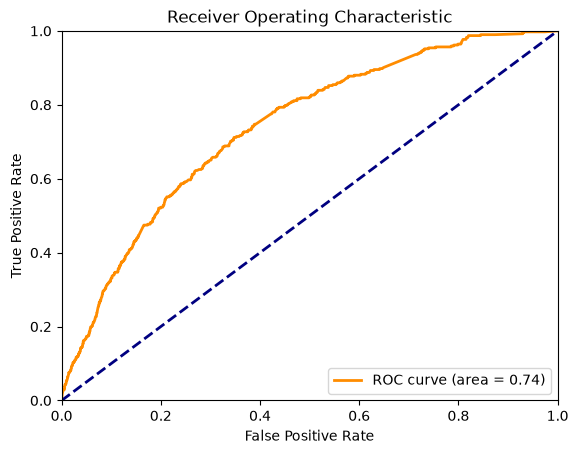

In [43]:
# ROC curve for model 3
# Get predicted probabilities for model 3
X = df[['SLQ120', 'INDFMPIR']]
X = sm.add_constant(X)
y_predicted_probs = model3.predict(X)
# Compute ROC curve and AUC
fpr, tpr, thresholds = metrics.roc_curve(df['depression'], y_predicted_probs)
roc_auc_score = metrics.auc(fpr, tpr)
# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig(r"C:\Users\brigi\source\repos\brigitschroeder\public\images\003-income-sleepiness-depression-roc-curve.png", dpi=150, bbox_inches='tight')
plt.show()

An AUC of 0.74 is meaningful. AUC represents the probability that the model will rank a randomly chosen depressed person higher than a randomly chosen non-depressed person. So the model correctly ranks that pair 74% of the time. Random chance (0.5) is represented by the dashed line. An AUC of 0.74 is considered an acceptable discrimination (not "excellent" 0.8-0.9, or "outstanding" above 0.9).

In [32]:
# Construct a confusion matrix for model 3 using a threshold of 0.5
# Get predicted classes for model 3 using a threshold of 0.5
y_predicted_classes = (y_predicted_probs >= 0.5).astype(int)
confusion_matrix = metrics.confusion_matrix(df['depression'], y_predicted_classes)
print(confusion_matrix)

[[4041    0]
 [ 392    0]]


Using a threshold of 0.5, the model predicted everyone as non-depressed (all zeros). Because only 9% of people are depressed, the model learned that the safest strategy is to always predict 0. This is a consequence of class imbalance, not evidence that the model learned nothing. An AUC of 0.74 confirms that the model does discriminate, just not at a threshold of 0.5.

The choice of threshold depends on clinical objectives. Do we want the model to be more sensitive (catch as many true cases as possible) or more specific (avoid false alarms). At a lower threshold, we get a lot more true positives but because of the relative rarity of true positives, we'll also get a lot more false positives too. In a real-life clinical setting the consequence of missing a depressed person (false negative resulting in delayed or absent treatment) needs to be compared with the consequence of flagging someone incorrectly (false positive resulting in unnecessary follow-up, potential stigma, wasted clinical resources). The choice depends on what happens after the positive screening.

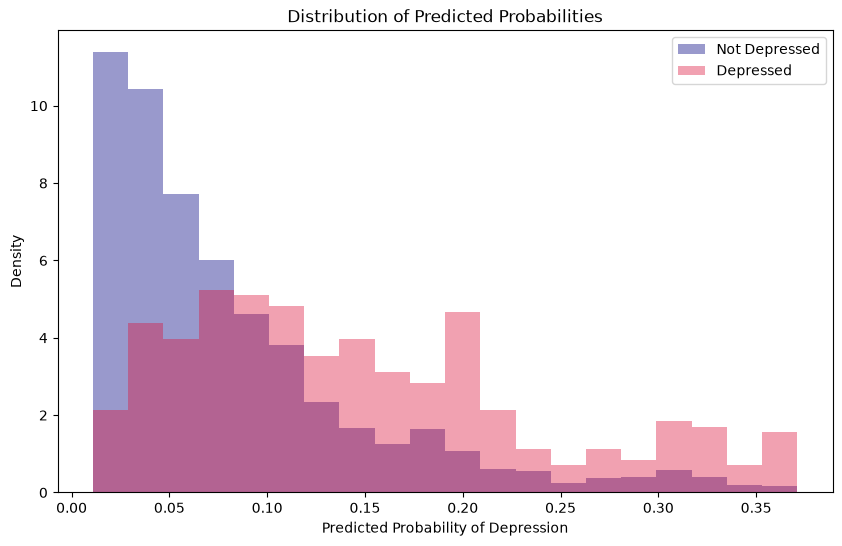

In [45]:
# Predicted probabilities.
# Plot the distribution of predicted probabilities for the two classes (depressed and not depressed)
plt.figure(figsize=(10,6))
plt.hist(y_predicted_probs[df['depression'] == 0], bins=20, alpha=0.4, label='Not Depressed', color='navy', density=True)
plt.hist(y_predicted_probs[df['depression'] == 1], bins=20, alpha=0.4, label='Depressed', color='crimson', density=True)
plt.xlabel('Predicted Probability of Depression')
plt.ylabel('Density')
plt.title('Distribution of Predicted Probabilities')
plt.legend(loc='upper right')
plt.savefig(r"C:\Users\brigi\source\repos\brigitschroeder\public\images\003-income-sleepiness-depression-predicted-probabilities.png", dpi=150, bbox_inches='tight')
plt.show()

The predicted probabilities plot shows that most not-depressed people get assigned probabilities below 0.05 (the blue distribution drops off sharply). The red distribution is flatter and extends further right, showing that depressed people tend to get higher probabilities than non-depressed people. But there's a lot of overlap in the 0.05-0.20 range. The model discriminates but imperfectly. Notice that the maximum predicted probability is only about 0.38 which is why the cutoff of 0.5 for the confusion matrix resulted in no one getting classified as depressed.